In [1]:
import os
from pathlib import Path
from dataclasses import dataclass
from anndata import AnnData
import scanpy as sc

In [2]:
# Add parent directory to path
os.chdir("/workspace/")

# Import STAGM
from src.adata_processing import (
    BatchAdataLoader,
    SingleAdataLoader
)
from src.stagm import STAGM

/opt/conda/envs/stagm-env/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/opt/conda/envs/stagm-env/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [3]:
# Dataclass for the configuration of the model
@dataclass
class ModelConfig:
    seed: int
    learning_rate: float
    num_hidden: int
    num_proj_hidden: int
    activation: str
    num_layers: int
    drop_feature_rate_1: float
    drop_feature_rate_2: float
    tau: float
    num_epochs: int
    weight_decay: float
    num_clusters: int
    num_gene: int
    num_neigh: int
    k: int
    dropout: float
    order_by_degree: bool
    shuffle_ind: int
    d_state: int
    d_conv: int
    bidirectional: bool


# Dataclass for the configuration of the dataset
@dataclass
class DatasetConfig:
    dataset: str
    label: bool
    file_list: list[str]
    slide: str

In [4]:
# Initialize the model configuration with the specified parameters
model_config = ModelConfig(
    seed=39788,
    learning_rate=0.0005,
    num_hidden=64,
    num_proj_hidden=64,
    activation="prelu",
    num_layers=1,
    drop_feature_rate_1=0.1,
    drop_feature_rate_2=0.2,
    tau=65,
    num_epochs=600,
    weight_decay=1e-05,
    num_clusters=25,
    num_gene=None,
    num_neigh=6,
    k=80,
    dropout=0.0,
    shuffle_ind=0,               
    d_state=16,
    d_conv=4,
    order_by_degree=True,
    bidirectional=True
)


# Initialize the dataset configuration with the specified parameters
args = DatasetConfig(
    dataset="visium", 
    label=False,
    file_list=['Mouse_Brain_Anterior', 'Mouse_Brain_Posterior'],
    slide='integration_horizontal'
)

In [5]:
# Define the base folder and the path to the specific dataset and slide
dataset_path = os.path.join("./Dataset", args.dataset)  # -> "./data/DLPFC"

In [6]:
loader = BatchAdataLoader(
    dataset_path=dataset_path,
    file_list=args.file_list,
    n_top_genes=model_config.num_gene, # 2296 — see note #1 below
    n_neighbors=model_config.num_neigh,# BatchAdataLoader's arg is `n_neighbors`, not `num_neigh`
    image_emb=False,
    label=args.label,                  # True
    # filter_na=True,
    # normalize=True,                    # False if these slices are already normalized/log1p'd
)

adata = loader.run()

now load: Mouse_Brain_Anterior
now load: Mouse_Brain_Posterior
load all slices done
merged feat shape: (6050, 1111)
merge done


/opt/conda/envs/stagm-env/lib/python3.11/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
Edge probabilities: 100%|██████████| 6050/6050 [00:00<00:00, 77314.71it/s]

merge adata load done


In [7]:
model_config.num_gene = adata.obsm["feat"].shape[1]
print(model_config.num_gene)

1111


In [8]:
# Initialize the STAGM model with the specified parameters and assign the loaded AnnData object to it
stagm = STAGM(args=args, config=model_config, single=True, refine=False)
stagm.adata = adata

In [9]:
stagm.train()

Consider intra slice
=== train ===


100%|██████████| [00:32<00:00, 18.39it/s]


In [10]:
# Evaluate the STAGM model
stagm.eva()

=== load ===

========== Model Diagnostics ==========
  Total parameters:     213,720
  Trainable parameters: 213,720
  Model weight size:    0.82 MB
  Peak GPU memory:      1871.94 MB
  Training time:        0m 32.6s  (32.6s total)
  Time per epoch:       54.4 ms

  Loss curve (total):     first=9.2426  last=8.7828  min=8.7825  max=9.2426

  Loss curve (recon):     first=0.5332  last=0.0823  min=0.0820  max=0.5332

  Embedding shape:      (6050, 64)
  Embedding norm — mean=24.3028  std=7.2067  min=5.6693  max=39.7365

embedding generated, go clustering


In [11]:
stagm.cluster(args.label)

Searching resolution...


Cluster count 12 is too small, adjusting end upward...
Cluster count 13 is too small, adjusting end upward...
Cluster count 17 is too small, adjusting end upward...
Cluster count 18 is too small, adjusting end upward...
Cluster count 18 is too small, adjusting end upward...
Cluster count 21 is too small, adjusting end upward...
Cluster count 21 is too small, adjusting end upward...
Cluster count 24 is too small, adjusting end upward...
Cluster count 24 is too small, adjusting end upward...
resolution=1.1650, cluster number=27
resolution=1.1600, cluster number=27
resolution=1.1550, cluster number=27
resolution=1.1500, cluster number=27
resolution=1.1450, cluster number=27
resolution=1.1400, cluster number=26
resolution=1.1350, cluster number=26
resolution=1.1300, cluster number=25
resolution=1.1250, cluster number=25
resolution=1.1200, cluster number=25
resolution=1.1150, cluster number=24
resolution=1.1100, cluster number=23
Best resolution found: 1.1300
calculate SC and DB
SC: 0.26397

In [12]:
import seaborn as sns
rgb_values = sns.color_palette("tab20", len(stagm.adata.obs['domain'].unique()))
color_fine = dict(zip(list(stagm.adata.obs['domain'].unique()), rgb_values))

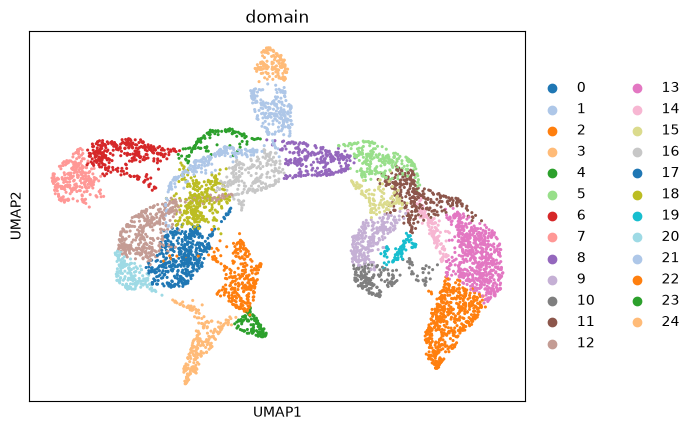

In [13]:
sc.pp.neighbors(stagm.adata, use_rep='emb')
sc.tl.umap(stagm.adata)
sc.pl.umap(stagm.adata, color='domain',palette=color_fine, show=True,save='mouse_domain.pdf')
# sc.pl.umap(stagm.adata, color='batch', show=True,save='mouse_batch.pdf')

/opt/conda/envs/stagm-env/lib/python3.11/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


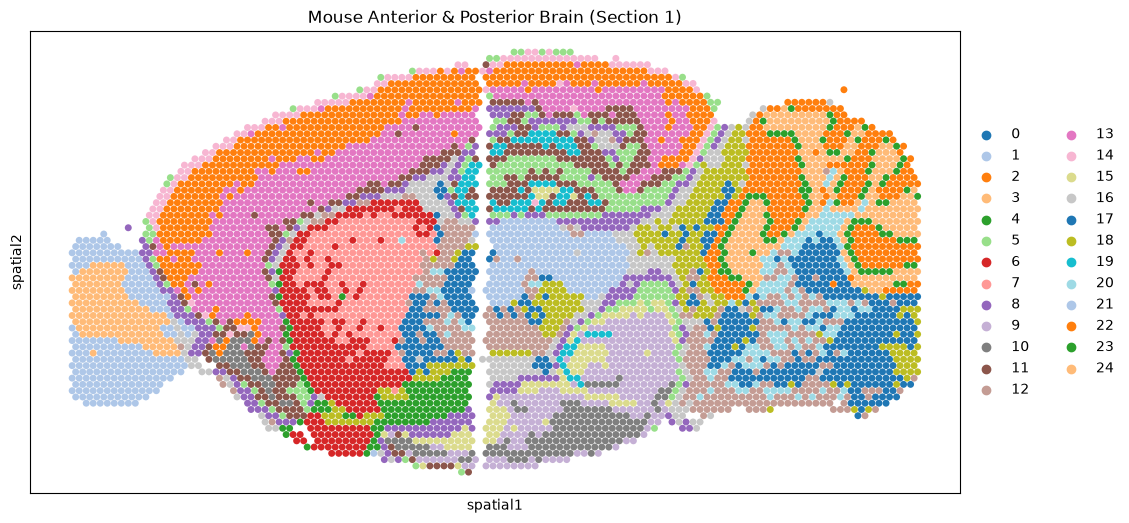

In [14]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)
data_all = sc.read_h5ad('./Dataset/9.Mouse_Brain_Merge_Anterior_Posterior_Section_1/filtered_feature_bc_matrix.h5ad') #It merely utilizes already aligned coordinates for better demonstration.
data_all.obsm['spatial'][:,1] = -1*data_all.obsm['spatial'][:,1]
stagm.adata.obsm['spatial']=data_all.obsm['spatial']
sc.pl.embedding(stagm.adata, basis="spatial",
                    color="domain",save='mouse.pdf',
                    s=100,
                    show=True,
                    palette=color_fine,
                    title='Mouse Anterior & Posterior Brain (Section 1)')